# EPL Match Performance & Home Advantage (2021–2024): Statistical Analysis & Insights

This notebook reproduces the **statistical analysis, correlation analysis, and insights** for our EPL project using the Kaggle dataset (*English Premier League Stats 2021–2024*).

**What this notebook does:**
- Cleans and normalizes the dataset (**mixed date formats** + **attendance formatting**)
- Builds key targets (e.g., `home_win_binary`) and engineered features (home–away **differentials**)
- Quantifies **home advantage** (win rates and goal differences)
- Computes correlations with `home_win_binary` (Pearson + Spearman) + bar charts and a correlation heatmap
- Tests associations (Welch t-tests + effect sizes + bootstrap CIs + FDR correction)
- Handles **COVID closed-door matches** (`attendance == 0`) explicitly

> **Data file**: put `mydata.csv` in the same directory as this notebook (or update `DATA_PATH` below).

In [3]:
# --- Setup
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.figsize"] = (10, 5)

In [4]:
DATA_PATH = "mydata.csv"  

df_raw = pd.read_csv(DATA_PATH)
df_raw.shape

(1140, 40)

## 1) Cleaning & normalization

This dataset contains:
- **Mixed date formats**: e.g., `13th August 2021` and later `23/05/2021` (UK day/month/year).
- **Attendance formatting**: values like `"60,095"` plus zeros during COVID closed-door matches.

We normalize column names, parse dates robustly, clean attendance to numeric, and create:
- `date_dt`, `calendar_year`, `season_start`, `season_label`
- `outcome_hda` in {H, D, A}
- `home_win_binary` (1 = Home Win, 0 = Draw or Away Win)
- `closed_doors` (1 when attendance==0)

In [5]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [
        re.sub(r"[^a-z0-9]+", "_", c.strip().lower()).strip("_")
        for c in df.columns
    ]
    return df

def parse_mixed_epl_dates(date_series: pd.Series) -> pd.Series:
    s = date_series.astype(str).str.strip()
    # Remove ordinal suffixes: 13th -> 13, 1st -> 1, etc.
    s_no_ord = s.str.replace(r"(\d+)(st|nd|rd|th)", r"\1", regex=True)
    # Identify slash dates like 23/05/2021
    mask_slash = s_no_ord.str.match(r"^\d{1,2}/\d{1,2}/\d{4}$", na=False)

    dt = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    # Parse slash dates explicitly as DAY/MONTH/YEAR (UK style)
    dt.loc[mask_slash] = pd.to_datetime(
        s_no_ord.loc[mask_slash],
        format="%d/%m/%Y",
        errors="coerce",
    )
    # Parse the rest (e.g., '13 August 2021', '28 May 2023')
    dt.loc[~mask_slash] = pd.to_datetime(
        s_no_ord.loc[~mask_slash],
        errors="coerce",
        dayfirst=True,
    )
    return dt

def clean_epl_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = normalize_columns(df)

    # Attendance: '"60,095"' -> 60095
    if "attendance" in df.columns:
        df["attendance"] = (
            df["attendance"].astype(str)
            .str.replace('"', "", regex=False)
            .str.replace(",", "", regex=False)
        )
        df["attendance"] = pd.to_numeric(df["attendance"], errors="coerce")

    # Date parsing
    if "date" in df.columns:
        df["date_dt"] = parse_mixed_epl_dates(df["date"])
        df["calendar_year"] = df["date_dt"].dt.year.astype("Int64")

        # EPL season starts around Aug
        season_start_year = np.where(
            df["date_dt"].dt.month >= 8,
            df["date_dt"].dt.year,
            df["date_dt"].dt.year - 1,
        )
        df["season_start"] = pd.Series(season_start_year, index=df.index).astype("Int64")
        df["season_end"] = (df["season_start"] + 1).astype("Int64")
        df["season_label"] = df["season_start"].astype(str) + "-" + df["season_end"].astype(str).str[-2:]

    # Goals: some Kaggle versions have 'goals_home' and 'away_goals'
    if "goals_home" in df.columns and "home_goals" not in df.columns:
        df["home_goals"] = pd.to_numeric(df["goals_home"], errors="coerce")
    if "home_goals" in df.columns:
        df["home_goals"] = pd.to_numeric(df["home_goals"], errors="coerce")
    if "away_goals" in df.columns:
        df["away_goals"] = pd.to_numeric(df["away_goals"], errors="coerce")

    # Outcome from class (h/d/a) if present
    if "class" in df.columns:
        df["outcome_hda"] = df["class"].astype(str).str.lower().map({"h": "H", "d": "D", "a": "A"})
    else:
        # fallback from goals
        df["outcome_hda"] = np.where(
            df["home_goals"] > df["away_goals"],
            "H",
            np.where(df["home_goals"] == df["away_goals"], "D", "A"),
        )

    df["home_win_binary"] = (df["outcome_hda"] == "H").astype(int)
    df["is_draw"] = (df["outcome_hda"] == "D").astype(int)

    # Derived columns
    if "home_goals" in df.columns and "away_goals" in df.columns:
        df["goal_diff"] = df["home_goals"] - df["away_goals"]

    if "home_possessions" in df.columns and "away_possessions" in df.columns:
        df["home_possessions"] = pd.to_numeric(df["home_possessions"], errors="coerce")
        df["away_possessions"] = pd.to_numeric(df["away_possessions"], errors="coerce")
        df["possession_diff"] = df["home_possessions"] - df["away_possessions"]

    # COVID / closed doors
    if "attendance" in df.columns:
        df["closed_doors"] = df["attendance"].fillna(0).eq(0).astype(int)
        df["attendance_nonzero"] = df["attendance"].where(df["attendance"] > 0, np.nan)

    # Teams as strings (some versions encode as IDs)
    for c in ["home_team", "away_team"]:
        if c in df.columns:
            df[c] = df[c].astype(str)

    return df

df = clean_epl_dataset(df_raw)
df.shape, df.columns[:12]

((1140, 53),
 Index(['date', 'clock', 'stadium', 'class', 'attendance', 'home_team',
        'goals_home', 'away_team', 'away_goals', 'home_possessions',
        'away_possessions', 'home_shots'],
       dtype='object'))

In [6]:
df.head(5)

,date,clock,stadium,class,attendance,home_team,goals_home,away_team,away_goals,home_possessions,...,season_end,season_label,home_goals,outcome_hda,home_win_binary,is_draw,goal_diff,possession_diff,closed_doors,attendance_nonzero
0,28th May 2023,4:30pm,Emirates Stadium,h,60095,2,5,13,0,51.0,...,2023,2022-23,5,H,1,0,5,2.0,0,60095.0
1,28th May 2023,4:30pm,Villa Park,h,42212,7,2,6,1,40.3,...,2023,2022-23,2,H,1,0,1,-19.4,0,42212.0
2,28th May 2023,4:30pm,Gtech Community Stadium,h,17120,9,1,1,0,34.4,...,2023,2022-23,1,H,1,0,1,-31.2,0,17120.0
3,28th May 2023,4:30pm,Stamford Bridge,d,40130,12,1,4,1,64.4,...,2023,2022-23,1,D,0,1,0,28.8,0,40130.0
4,28th May 2023,4:30pm,Selhurst Park,d,25198,11,1,16,1,66.0,...,2023,2022-23,1,D,0,1,0,32.0,0,25198.0


### Quick sanity checks

In [7]:
# How many dates did not parse?
unparsed = df["date_dt"].isna().sum() if "date_dt" in df.columns else None
unparsed

np.int64(0)

In [8]:
# Attendance zeros (closed doors)
if "attendance" in df.columns:
    df["closed_doors"].value_counts(dropna=False)

## 2) Feature engineering: home–away differentials

For any numeric pair `home_X` and `away_X`, we create `X_diff = home_X - away_X`.

In [9]:
def build_home_away_diffs(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    cols = df.columns
    home_cols = [c for c in cols if c.startswith("home_")]
    for hc in home_cols:
        base = hc.replace("home_", "", 1)
        ac = "away_" + base
        if ac in cols and pd.api.types.is_numeric_dtype(df[hc]) and pd.api.types.is_numeric_dtype(df[ac]):
            diff_name = f"{base}_diff"
            if diff_name not in df.columns:
                df[diff_name] = df[hc] - df[ac]
    return df

df = build_home_away_diffs(df)
diff_cols = [c for c in df.columns if c.endswith("_diff")]
len(diff_cols), diff_cols[:15]

(18,
 ['goal_diff',
  'possession_diff',
  'possessions_diff',
  'shots_diff',
  'on_diff',
  'off_diff',
  'blocked_diff',
  'pass_diff',
  'chances_diff',
  'corners_diff',
  'offside_diff',
  'tackles_diff',
  'duels_diff',
  'saves_diff',
  'fouls_diff'])

## 3) Home advantage: descriptive results

In [10]:
home_win_rate = df["home_win_binary"].mean()
draw_rate = df["is_draw"].mean()
away_win_rate = (df["outcome_hda"] == "A").mean()
home_win_rate, draw_rate, away_win_rate

(np.float64(0.43333333333333335),
 np.float64(0.22456140350877193),
 np.float64(0.34210526315789475))

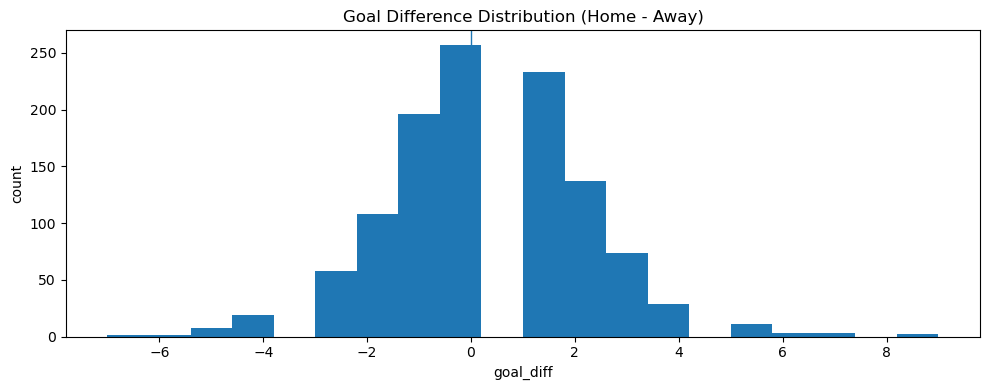

In [11]:
# Goal difference distribution
if "goal_diff" in df.columns:
    plt.figure(figsize=(10,4))
    plt.hist(df["goal_diff"].dropna(), bins=20)
    plt.axvline(0, linewidth=1)
    plt.title("Goal Difference Distribution (Home - Away)")
    plt.xlabel("goal_diff")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

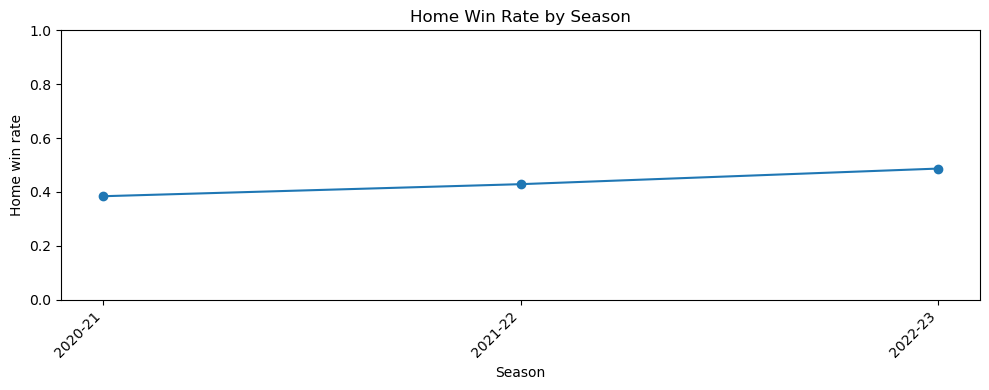

In [12]:
# Home win rate by season label (if available)
if "season_label" in df.columns:
    s = df.groupby("season_label")["home_win_binary"].mean().sort_index()
    plt.figure(figsize=(10,4))
    plt.plot(s.index, s.values, marker="o")
    plt.ylim(0,1)
    plt.title("Home Win Rate by Season")
    plt.xlabel("Season")
    plt.ylabel("Home win rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### COVID closed doors: compare home win rate with and without crowds

In [13]:
if "closed_doors" in df.columns:
    rate_closed = df.loc[df["closed_doors"]==1, "home_win_binary"].mean()
    rate_open = df.loc[df["closed_doors"]==0, "home_win_binary"].mean()
    rate_closed, rate_open

## 4) Correlation analysis with `home_win_binary`

In [14]:
def corr_with_target(df: pd.DataFrame, target="home_win_binary", features=None, method="pearson") -> pd.DataFrame:
    if features is None:
        features = df.select_dtypes(include=[np.number]).columns.tolist()
    features = [c for c in features if c != target]

    out = []
    for c in features:
        s = df[[c, target]].dropna()
        if s.empty or s[c].nunique() < 2:
            continue
        if method == "spearman":
            r, _ = stats.spearmanr(s[c], s[target])
        else:
            r = np.corrcoef(s[c], s[target])[0, 1]
        out.append((c, r, len(s)))

    res = pd.DataFrame(out, columns=["feature", "corr", "n"]).sort_values(
        "corr", key=lambda x: x.abs(), ascending=False
    )
    return res

feature_pool = []
feature_pool += [c for c in diff_cols if pd.api.types.is_numeric_dtype(df[c])]
for c in ["attendance", "attendance_nonzero", "possession_diff", "home_possessions", "away_possessions"]:
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
        feature_pool.append(c)
feature_pool = list(dict.fromkeys(feature_pool))

pear = corr_with_target(df, features=feature_pool, method="pearson")
spear = corr_with_target(df, features=feature_pool, method="spearman")

pear.head(10), spear.head(10)

(               feature      corr     n
 0            goal_diff  0.768410  1140
 17          goals_diff  0.768410  1140
 4              on_diff  0.499046  1140
 8         chances_diff  0.410164  1140
 3           shots_diff  0.303964  1140
 19  attendance_nonzero  0.248547   760
 18          attendance  0.173406  1140
 13          saves_diff -0.153715  1140
 16            red_diff -0.149801  1140
 21    away_possessions -0.124926  1140,
                feature      corr     n
 0            goal_diff  0.858632  1140
 17          goals_diff  0.858632  1140
 4              on_diff  0.510856  1140
 8         chances_diff  0.421339  1140
 3           shots_diff  0.307869  1140
 19  attendance_nonzero  0.246608   760
 18          attendance  0.170621  1140
 13          saves_diff -0.151962  1140
 16            red_diff -0.144984  1140
 6         blocked_diff  0.122875  1140)

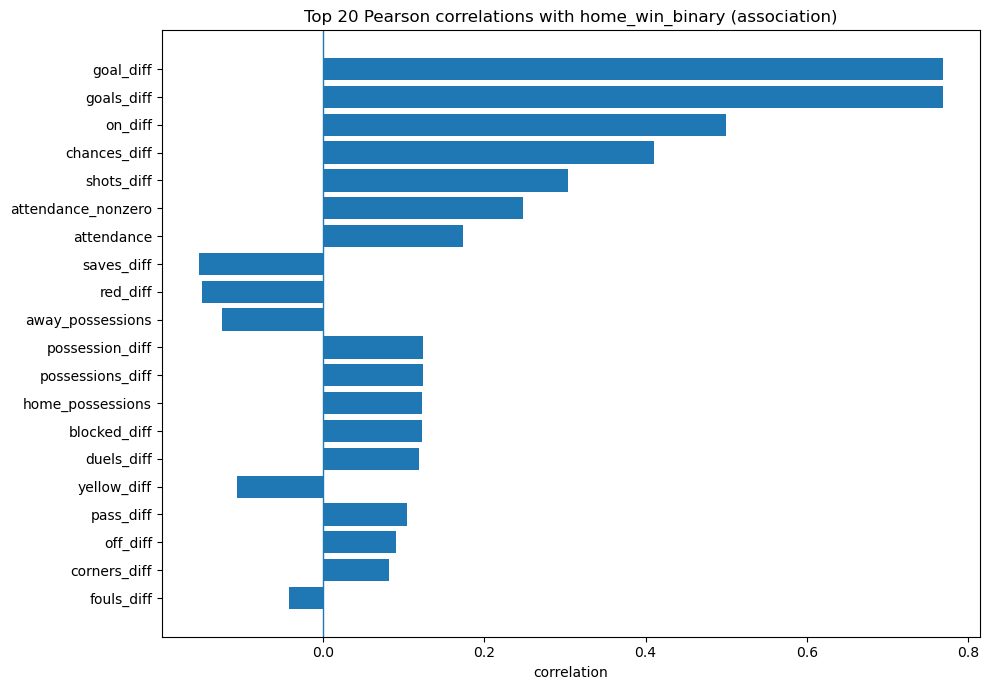

In [15]:
# Bar chart: top Pearson correlations
top_n = 20
plot_df = pear.head(top_n).iloc[::-1]
plt.figure(figsize=(10, max(5, 0.35*len(plot_df))))
plt.barh(plot_df["feature"], plot_df["corr"])
plt.axvline(0, linewidth=1)
plt.title(f"Top {top_n} Pearson correlations with home_win_binary (association)")
plt.xlabel("correlation")
plt.tight_layout()
plt.show()

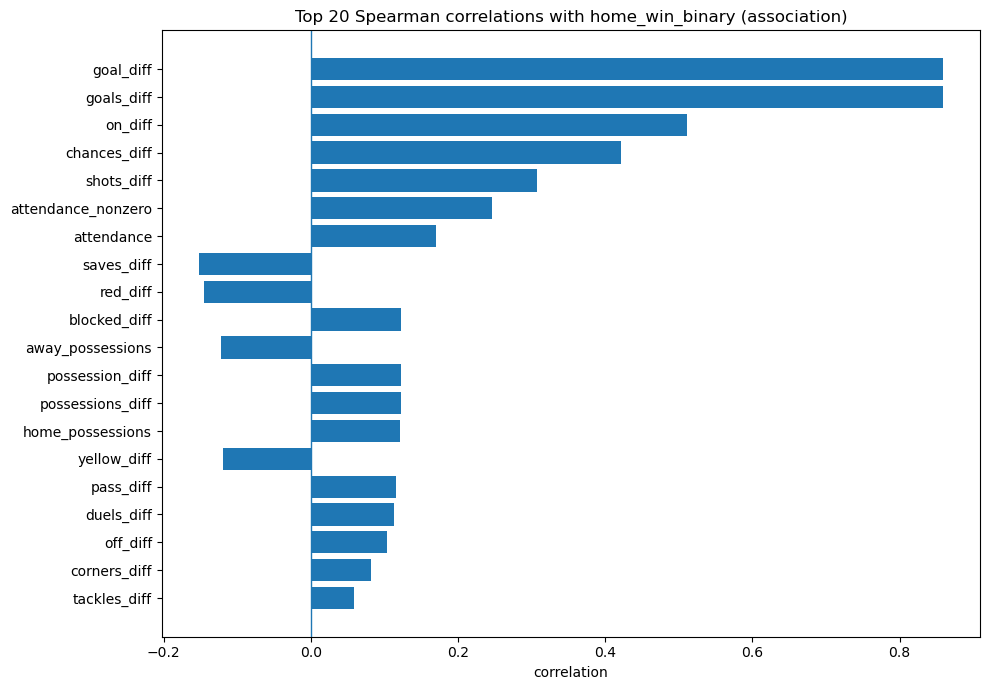

In [16]:
# Bar chart: top Spearman correlations
top_n = 20
plot_df = spear.head(top_n).iloc[::-1]
plt.figure(figsize=(10, max(5, 0.35*len(plot_df))))
plt.barh(plot_df["feature"], plot_df["corr"])
plt.axvline(0, linewidth=1)
plt.title(f"Top {top_n} Spearman correlations with home_win_binary (association)")
plt.xlabel("correlation")
plt.tight_layout()
plt.show()

### Correlation heatmap (improved colors)

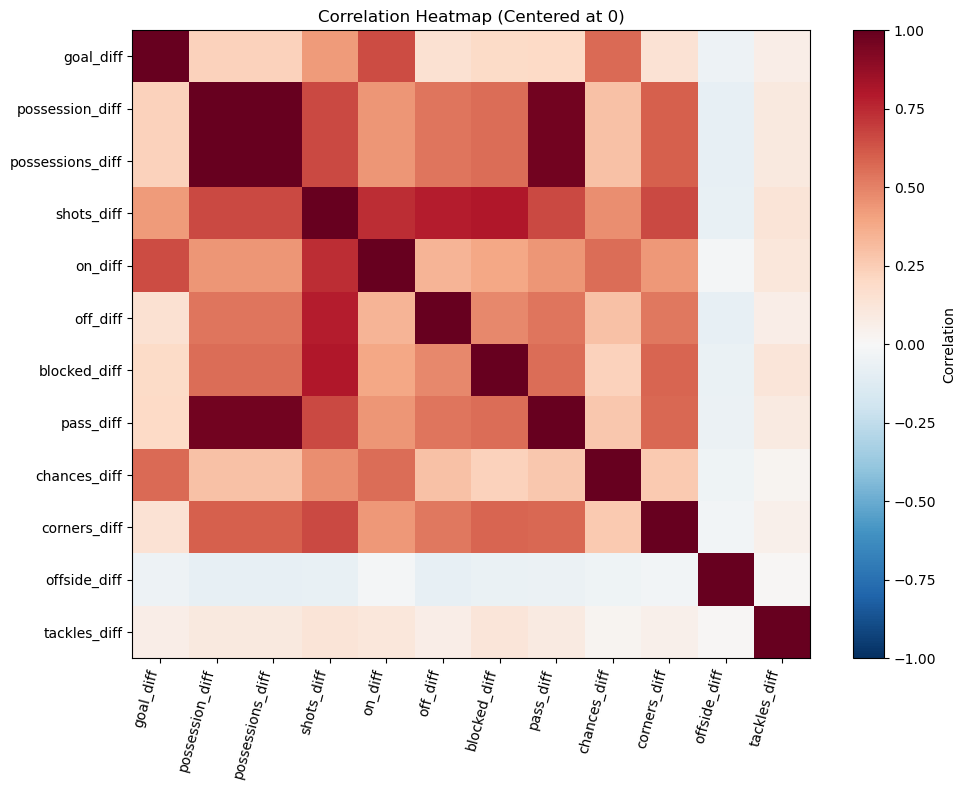

In [17]:
heat_candidates = [c for c in diff_cols if any(k in c for k in ["shots", "on", "fouls", "yellow", "red", "corners", "pass", "chances", "possession"])]
heat_sel = heat_candidates[:12] if len(heat_candidates) >= 12 else diff_cols[:12]

if len(heat_sel) >= 3:
    m = df[heat_sel].corr(numeric_only=True)

    vmax = np.nanmax(np.abs(m.values))
    vmin, vmax = (-vmax, vmax) if np.isfinite(vmax) else (-1, 1)

    plt.figure(figsize=(10, 8))
    plt.imshow(m.values, aspect="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax)
    plt.colorbar(label="Correlation")
    plt.xticks(range(len(heat_sel)), heat_sel, rotation=75, ha="right")
    plt.yticks(range(len(heat_sel)), heat_sel)
    plt.title("Correlation Heatmap (Centered at 0)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough diff features for a heatmap.")

## 5) Attendance & possession visuals (requested plots)

C:\Users\fzawa\AppData\Local\Temp\ipykernel_73428\698231616.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([win.values, notwin.values], labels=["Home Win", "Not Home Win"])


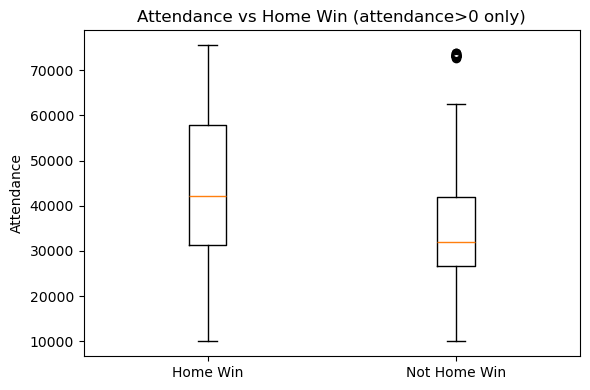

In [18]:
# Attendance vs Home Win (box/whisker) — exclude closed doors by default
if "attendance" in df.columns:
    att_df = df[df["attendance"] > 0].copy()  # exclude attendance=0
    win = att_df.loc[att_df["home_win_binary"]==1, "attendance"].dropna()
    notwin = att_df.loc[att_df["home_win_binary"]==0, "attendance"].dropna()

    if len(win) >= 2 and len(notwin) >= 2:
        plt.figure(figsize=(6,4))
        plt.boxplot([win.values, notwin.values], labels=["Home Win", "Not Home Win"])
        plt.ylabel("Attendance")
        plt.title("Attendance vs Home Win (attendance>0 only)")
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough non-zero attendance data for both groups to boxplot.")
else:
    print("No attendance column found.")

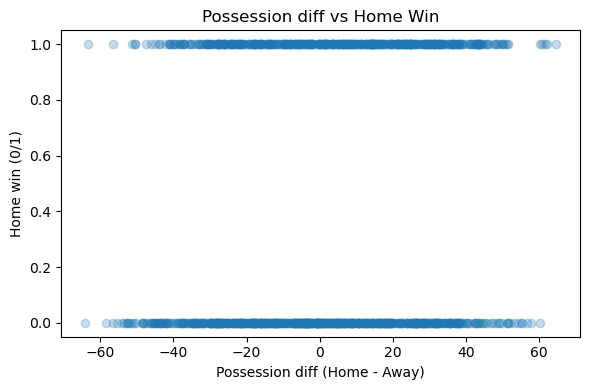

In [19]:
# Possession diff vs Home Win (scatter)
if "possession_diff" in df.columns:
    plt.figure(figsize=(6,4))
    plt.scatter(df["possession_diff"], df["home_win_binary"], alpha=0.25)
    plt.xlabel("Possession diff (Home - Away)")
    plt.ylabel("Home win (0/1)")
    plt.title("Possession diff vs Home Win")
    plt.tight_layout()
    plt.show()
else:
    print("possession_diff not available.")

## 6) Association tests (Welch t-test + effect size + bootstrap CI + FDR)

In [20]:
def cohens_d(x, y) -> float:
    x, y = np.array(x), np.array(y)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    pooled = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled if pooled > 0 else np.nan

def bootstrap_ci_diff_means(x, y, n_boot=2000, ci=0.95, seed=42):
    rng = np.random.default_rng(seed)
    x = np.array(x); y = np.array(y)
    x = x[~np.isnan(x)]; y = y[~np.isnan(y)]
    if len(x) < 2 or len(y) < 2:
        return (np.nan, np.nan, np.nan)
    diffs = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        diffs[i] = xb.mean() - yb.mean()
    alpha = (1 - ci) / 2
    lo = np.quantile(diffs, alpha)
    hi = np.quantile(diffs, 1 - alpha)
    return (x.mean() - y.mean(), lo, hi)

def compare_groups(df: pd.DataFrame, feature: str, target="home_win_binary", n_boot=2000) -> dict:
    s = df[[feature, target]].dropna()
    g1 = s[s[target] == 1][feature]
    g0 = s[s[target] == 0][feature]
    if g1.shape[0] < 2 or g0.shape[0] < 2:
        return {
            "feature": feature,
            "n_home_win": int(g1.shape[0]),
            "n_not_home_win": int(g0.shape[0]),
            "mean_home_win": float(g1.mean()) if g1.shape[0] else np.nan,
            "mean_not_home_win": float(g0.mean()) if g0.shape[0] else np.nan,
            "mean_diff": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "p_value": np.nan,
            "cohens_d": np.nan,
        }
    _, p = stats.ttest_ind(g1, g0, equal_var=False, nan_policy="omit")
    d = cohens_d(g1, g0)
    mean_diff, lo, hi = bootstrap_ci_diff_means(g1, g0, n_boot=n_boot)
    return {
        "feature": feature,
        "n_home_win": int(g1.shape[0]),
        "n_not_home_win": int(g0.shape[0]),
        "mean_home_win": float(g1.mean()),
        "mean_not_home_win": float(g0.mean()),
        "mean_diff": float(mean_diff),
        "ci_low": float(lo),
        "ci_high": float(hi),
        "p_value": float(p),
        "cohens_d": float(d),
    }

def benjamini_hochberg(pvals: np.ndarray) -> np.ndarray:
    pvals = np.asarray(pvals, dtype=float)
    out = np.full(pvals.size, np.nan, dtype=float)
    valid = np.isfinite(pvals)
    pv = pvals[valid]
    if pv.size == 0:
        return out
    order = np.argsort(pv)
    ranked = pv[order]
    adj = ranked * (pv.size / (np.arange(1, pv.size + 1)))
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0, 1)
    out_valid = np.empty_like(pv)
    out_valid[order] = adj
    out[valid] = out_valid
    return out

In [21]:
test_features = []
if "attendance_nonzero" in df.columns:
    test_features.append("attendance_nonzero")
if "possession_diff" in df.columns:
    test_features.append("possession_diff")

top_diffs = pear[pear["feature"].isin(diff_cols)].head(15)["feature"].tolist()
test_features += top_diffs
test_features = list(dict.fromkeys(test_features))
test_features

['attendance_nonzero',
 'possession_diff',
 'goal_diff',
 'goals_diff',
 'on_diff',
 'chances_diff',
 'shots_diff',
 'saves_diff',
 'red_diff',
 'possessions_diff',
 'blocked_diff',
 'duels_diff',
 'yellow_diff',
 'pass_diff',
 'off_diff',
 'corners_diff']

In [22]:
rows = [compare_groups(df, f, n_boot=2000) for f in test_features]
res = pd.DataFrame(rows)

res["p_fdr_bh"] = benjamini_hochberg(res["p_value"].values)
res["sig_fdr_0_05"] = res["p_fdr_bh"] <= 0.05
res = res.sort_values(["p_fdr_bh", "cohens_d"], ascending=[True, False])

res.head(20)

,feature,n_home_win,n_not_home_win,mean_home_win,mean_not_home_win,mean_diff,ci_low,ci_high,p_value,cohens_d,p_fdr_bh,sig_fdr_0_05
2,goal_diff,494,646,1.917004,-1.091331,3.008335,2.871746,3.148491,2.959289e-215,2.420949,2.367431e-214,True
3,goals_diff,494,646,1.917004,-1.091331,3.008335,2.871746,3.148491,2.959289e-215,2.420949,2.367431e-214,True
4,on_diff,494,646,2.866397,-0.998452,3.864849,3.482901,4.240206,1.675371e-73,1.161121,8.935312e-73,True
5,chances_diff,494,646,1.143725,-0.515480,1.659205,1.446154,1.869624,2.601711e-47,0.906777,1.040684e-46,True
6,shots_diff,494,646,5.214575,-0.309598,5.524172,4.547874,6.492936,3.151026e-26,0.643306,1.008328e-25,True
0,attendance_nonzero,348,412,44160.540230,36257.881068,7902.659162,5613.519354,10086.518749,5.614736e-12,0.514350,1.497263e-11,True
7,saves_diff,494,646,-0.957490,-0.061920,-0.895570,-1.228057,-0.571922,1.408327e-07,-0.313655,3.219034e-07,True
8,red_diff,494,646,-0.058704,0.041796,-0.100500,-0.137893,-0.062274,3.354661e-07,-0.305483,6.709323e-07,True
1,possession_diff,494,646,5.263968,-1.182817,6.446785,3.262456,9.461126,2.683560e-05,0.251902,4.293696e-05,True
9,possessions_diff,494,646,5.263968,-1.182817,6.446785,3.262456,9.461126,2.683560e-05,0.251902,4.293696e-05,True


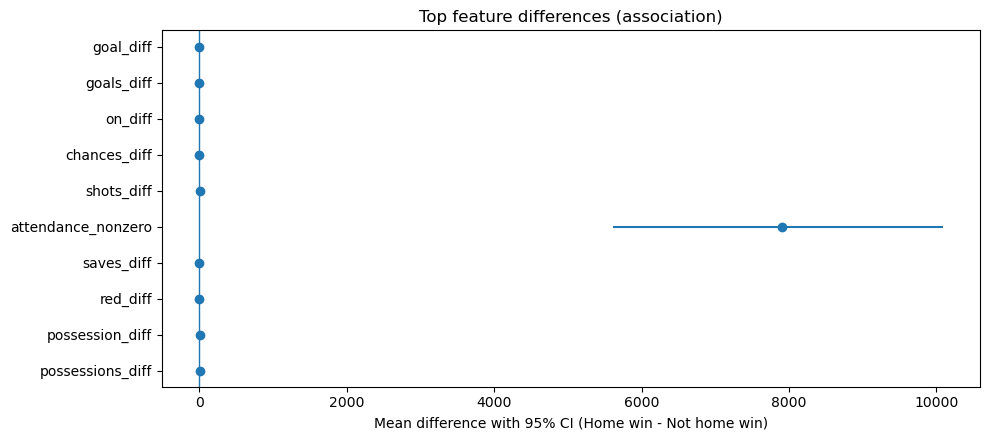

In [23]:
plot_k = min(10, len(res))
plot_res = res.head(plot_k).iloc[::-1]

y = np.arange(len(plot_res))
means = plot_res["mean_diff"].values
lo = plot_res["ci_low"].values
hi = plot_res["ci_high"].values
err_left = means - lo
err_right = hi - means

plt.figure(figsize=(10, max(4, 0.45*len(plot_res))))
plt.errorbar(means, y, xerr=[err_left, err_right], fmt="o")
plt.axvline(0, linewidth=1)
plt.yticks(y, plot_res["feature"])
plt.xlabel("Mean difference with 95% CI (Home win - Not home win)")
plt.title("Top feature differences (association)")
plt.tight_layout()
plt.show()

## 7) Trend + binned relationships (dashboard-friendly insights)

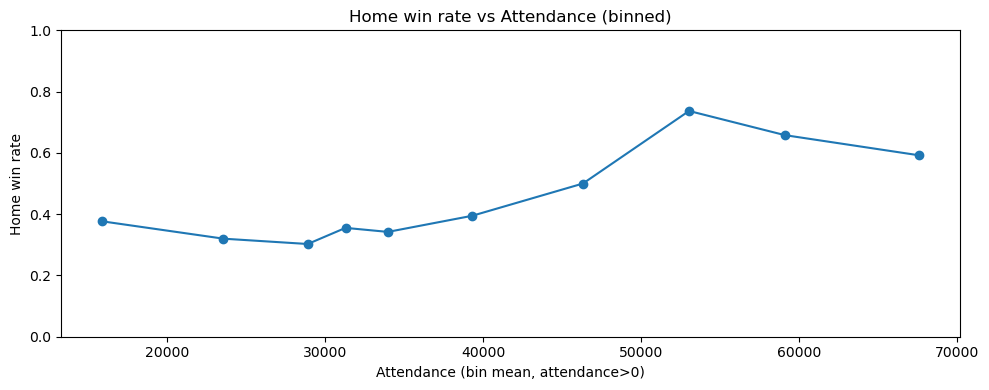

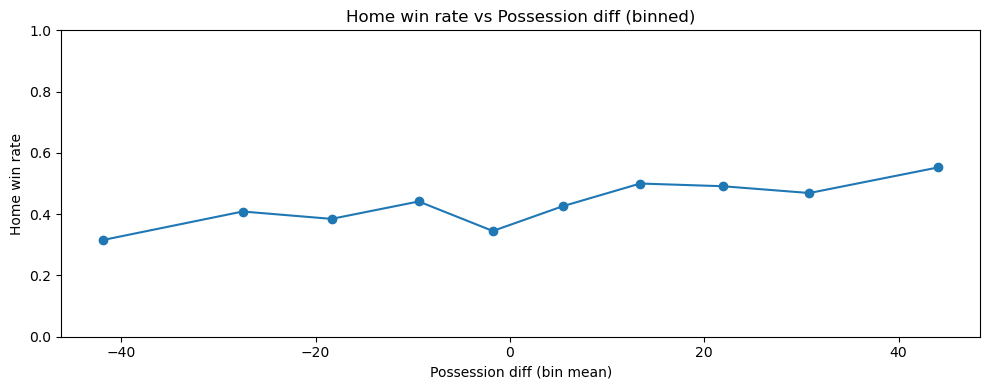

In [24]:
def binned_win_rate(df: pd.DataFrame, xcol: str, bins: int = 10) -> pd.DataFrame:
    s = df[[xcol, "home_win_binary"]].dropna()
    if s.empty or s[xcol].nunique() < bins:
        return pd.DataFrame()
    s = s.copy()
    s["bin"] = pd.qcut(s[xcol], q=bins, duplicates="drop")
    out = s.groupby("bin", observed=True).agg(
        n=("home_win_binary", "size"),
        home_win_rate=("home_win_binary", "mean"),
        x_mean=(xcol, "mean"),
    ).reset_index()
    return out

if "attendance_nonzero" in df.columns:
    bdf = binned_win_rate(df, "attendance_nonzero", bins=10)
    if not bdf.empty:
        plt.figure(figsize=(10,4))
        plt.plot(bdf["x_mean"], bdf["home_win_rate"], marker="o")
        plt.ylim(0,1)
        plt.xlabel("Attendance (bin mean, attendance>0)")
        plt.ylabel("Home win rate")
        plt.title("Home win rate vs Attendance (binned)")
        plt.tight_layout()
        plt.show()

if "possession_diff" in df.columns:
    bdf = binned_win_rate(df, "possession_diff", bins=10)
    if not bdf.empty:
        plt.figure(figsize=(10,4))
        plt.plot(bdf["x_mean"], bdf["home_win_rate"], marker="o")
        plt.ylim(0,1)
        plt.xlabel("Possession diff (bin mean)")
        plt.ylabel("Home win rate")
        plt.title("Home win rate vs Possession diff (binned)")
        plt.tight_layout()
        plt.show()

## 8) Interpreting results: association vs causation

- **In-match stats** (shots, fouls, cards, possession) can be influenced by **game state** 
- **Attendance** is potentially **confounded** by team strength/popularity.
- COVID closed-door matches create a mass at `attendance = 0`. We treat those separately using:
  - `closed_doors` indicator
  - `attendance_nonzero` for attendance analyses.

In [25]:
top_corr = pear.head(15)[["feature", "corr", "n"]]
top_corr

,feature,corr,n
0,goal_diff,0.768410,1140
17,goals_diff,0.768410,1140
4,on_diff,0.499046,1140
8,chances_diff,0.410164,1140
3,shots_diff,0.303964,1140
19,attendance_nonzero,0.248547,760
18,attendance,0.173406,1140
13,saves_diff,-0.153715,1140
16,red_diff,-0.149801,1140
21,away_possessions,-0.124926,1140


In [26]:
top_tests = res.head(15)[["feature", "mean_diff", "ci_low", "ci_high", "cohens_d", "p_value", "p_fdr_bh", "sig_fdr_0_05"]]
top_tests

,feature,mean_diff,ci_low,ci_high,cohens_d,p_value,p_fdr_bh,sig_fdr_0_05
2,goal_diff,3.008335,2.871746,3.148491,2.420949,2.959289e-215,2.367431e-214,True
3,goals_diff,3.008335,2.871746,3.148491,2.420949,2.959289e-215,2.367431e-214,True
4,on_diff,3.864849,3.482901,4.240206,1.161121,1.675371e-73,8.935312e-73,True
5,chances_diff,1.659205,1.446154,1.869624,0.906777,2.601711e-47,1.040684e-46,True
6,shots_diff,5.524172,4.547874,6.492936,0.643306,3.151026e-26,1.008328e-25,True
0,attendance_nonzero,7902.659162,5613.519354,10086.518749,0.514350,5.614736e-12,1.497263e-11,True
7,saves_diff,-0.895570,-1.228057,-0.571922,-0.313655,1.408327e-07,3.219034e-07,True
8,red_diff,-0.100500,-0.137893,-0.062274,-0.305483,3.354661e-07,6.709323e-07,True
1,possession_diff,6.446785,3.262456,9.461126,0.251902,2.683560e-05,4.293696e-05,True
9,possessions_diff,6.446785,3.262456,9.461126,0.251902,2.683560e-05,4.293696e-05,True
